In [ ]:
!pip install "datasets<4.0.0" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 12.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2025.3.0 which is incompatible.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("Hate-speech-CNERG/hatexplain", revision="refs/convert/parquet")
print(dataset)

plain_text/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.68MB            

plain_text/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/212k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/212k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})


In [ ]:
example = dataset['train'][0]
print(example)


{'id': '23107796_gab', 'annotators': {'label': [0, 2, 2], 'annotator_id': [203, 204, 233], 'target': [['Hindu', 'Islam'], ['Hindu', 'Islam'], ['Hindu', 'Islam', 'Other']]}, 'rationales': [[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'post_tokens': ['u', 'really', 'think', 'i', 'would', 'not', 'have', 'been', 'raped', 'by', 'feral', 'hindu', 'or', 'muslim', 'back', 'in', 'india', 'or', 'bangladesh', 'and', 'a', 'neo', 'nazi', 'would', 'rape', 'me', 'as', 'well', 'just', 'to', 'see', 'me', 'cry']}


In [ ]:
import pandas as pd

def process_split(split):
    rows = []
    for item in split:
        text = " ".join(item['post_tokens'])

        # annotators is now a dict of lists (columnar), not a list of dicts
        labels = item['annotators']['label']       # e.g. [0, 1, 0]
        targets = item['annotators']['target']     # e.g. [['Women'], ['None'], ['Women']]

        rows.append({
            'id': item['id'],
            'text': text,
            'annotator_labels': labels,
            'annotator_targets': targets
        })
    return pd.DataFrame(rows)

train_df = process_split(dataset['train'])
val_df = process_split(dataset['validation'])
test_df = process_split(dataset['test'])

print(train_df.shape)
train_df.head()

(15383, 4)


,id,text,annotator_labels,annotator_targets
0,23107796_gab,u really think i would not have been raped by ...,"[0, 2, 2]","[[Hindu, Islam], [Hindu, Islam], [Hindu, Islam..."
1,9995600_gab,the uk has threatened to return radioactive wa...,"[2, 2, 0]","[[Minority, Refugee, Indian], [Indian], [Refug..."
2,1227920812235051008_twitter,if english is not imposition then hindi is als...,"[2, 2, 2]","[[Other], [Hindu], [Hindu, Other]]"
3,1204931715778543624_twitter,no liberal congratulated hindu refugees post c...,"[2, 2, 2]","[[Hindu], [Hindu], [Hindu]]"
4,1179102559241244672_twitter,he said bro even your texts sound redneck what...,"[2, 2, 2]","[[Economic], [Economic], [Caucasian]]"


In [ ]:
from collections import Counter

def majority_label(label_list):
    count = Counter(label_list)
    most_common_label, freq = count.most_common(1)[0]
    return most_common_label

train_df['final_label'] = train_df['annotator_labels'].apply(majority_label)
val_df['final_label'] = val_df['annotator_labels'].apply(majority_label)
test_df['final_label'] = test_df['annotator_labels'].apply(majority_label)

print(train_df['final_label'].value_counts())

final_label
1    6251
0    4748
2    4384
Name: count, dtype: int64


In [ ]:
from collections import Counter

all_targets = []
for target_list in train_df['annotator_targets']:
    for annotator_targets in target_list:
        all_targets.extend(annotator_targets)

target_counts = Counter(all_targets)
print(target_counts.most_common())

[('None', 16452), ('African', 7727), ('Islam', 5068), ('Women', 4678), ('Jewish', 4560), ('Homosexual', 4269), ('Other', 3493), ('Refugee', 2230), ('Arab', 2209), ('Caucasian', 1783), ('Men', 1307), ('Asian', 1011), ('Hispanic', 987), ('Christian', 209), ('Disability', 181), ('Minority', 150), ('Heterosexual', 110), ('Hindu', 75), ('Economic', 74), ('Nonreligious', 68), ('Indian', 64), ('Indigenous', 59), ('Buddhism', 10), ('Bisexual', 6), ('Asexual', 3)]


In [ ]:
# Categories we keep individually (reasonable sample size)
individual_categories = ['African', 'Islam', 'Women', 'Jewish', 'Homosexual',
                          'Other', 'Refugee', 'Arab', 'Caucasian', 'Men',
                          'Asian', 'Hispanic']

# Rare categories we merge into one bucket
rare_categories = ['Christian', 'Disability', 'Minority', 'Heterosexual', 'Hindu',
                    'Economic', 'Nonreligious', 'Indian', 'Indigenous',
                    'Buddhism', 'Bisexual', 'Asexual']

def build_target_labels(target_lists, categories=individual_categories, rare=rare_categories):
    """
    target_lists: the 3-annotator list of lists, e.g. [['Hindu','Islam'], ['Islam'], ['Islam']]
    Returns a dict of binary flags using UNION rule (any annotator mentioning it counts).
    """
    # Flatten all annotators' mentions for this post into one set
    all_mentions = set()
    for annotator_targets in target_lists:
        all_mentions.update(annotator_targets)

    row = {}
    for cat in categories:
        row[f'target_{cat}'] = 1 if cat in all_mentions else 0

    # Grouped rare category
    row['target_Other_Minority'] = 1 if any(r in all_mentions for r in rare) else 0

    return row

# Apply to train/val/test
def add_target_columns(df):
    target_rows = df['annotator_targets'].apply(build_target_labels)
    target_df = pd.DataFrame(list(target_rows))
    return pd.concat([df.reset_index(drop=True), target_df], axis=1)

train_df = add_target_columns(train_df)
val_df = add_target_columns(val_df)
test_df = add_target_columns(test_df)

print(train_df.shape)
train_df.head()

(15383, 18)


,id,text,annotator_labels,annotator_targets,final_label,target_African,target_Islam,target_Women,target_Jewish,target_Homosexual,target_Other,target_Refugee,target_Arab,target_Caucasian,target_Men,target_Asian,target_Hispanic,target_Other_Minority
0,23107796_gab,u really think i would not have been raped by ...,"[0, 2, 2]","[[Hindu, Islam], [Hindu, Islam], [Hindu, Islam...",2,0,1,0,0,0,1,0,0,0,0,0,0,1
1,9995600_gab,the uk has threatened to return radioactive wa...,"[2, 2, 0]","[[Minority, Refugee, Indian], [Indian], [Refug...",2,0,1,0,0,0,0,1,0,0,0,0,0,1
2,1227920812235051008_twitter,if english is not imposition then hindi is als...,"[2, 2, 2]","[[Other], [Hindu], [Hindu, Other]]",2,0,0,0,0,0,1,0,0,0,0,0,0,1
3,1204931715778543624_twitter,no liberal congratulated hindu refugees post c...,"[2, 2, 2]","[[Hindu], [Hindu], [Hindu]]",2,0,0,0,0,0,0,0,0,0,0,0,0,1
4,1179102559241244672_twitter,he said bro even your texts sound redneck what...,"[2, 2, 2]","[[Economic], [Economic], [Caucasian]]",2,0,0,0,0,0,0,0,0,1,0,0,0,1


In [ ]:
target_cols = [c for c in train_df.columns if c.startswith('target_')]
print(train_df[target_cols].sum().sort_values(ascending=False))

target_African           3400
target_Women             2986
target_Other             2755
target_Islam             2415
target_Homosexual        1972
target_Jewish            1924
target_Arab              1331
target_Caucasian         1280
target_Men               1230
target_Refugee           1229
target_Other_Minority     721
target_Asian              540
target_Hispanic           529
dtype: int64


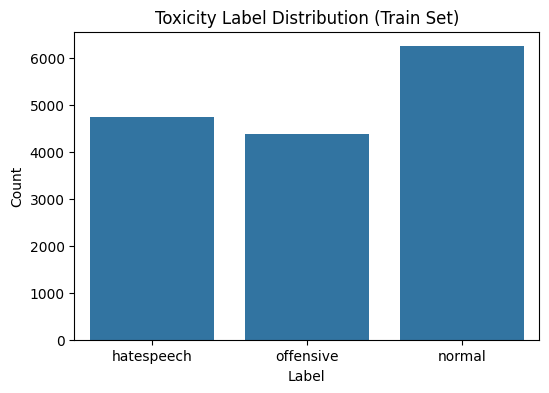

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_names = {0: 'hatespeech', 1: 'normal', 2: 'offensive'}
train_df['final_label_name'] = train_df['final_label'].map(label_names)

plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='final_label_name', order=['hatespeech','offensive','normal'])
plt.title('Toxicity Label Distribution (Train Set)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

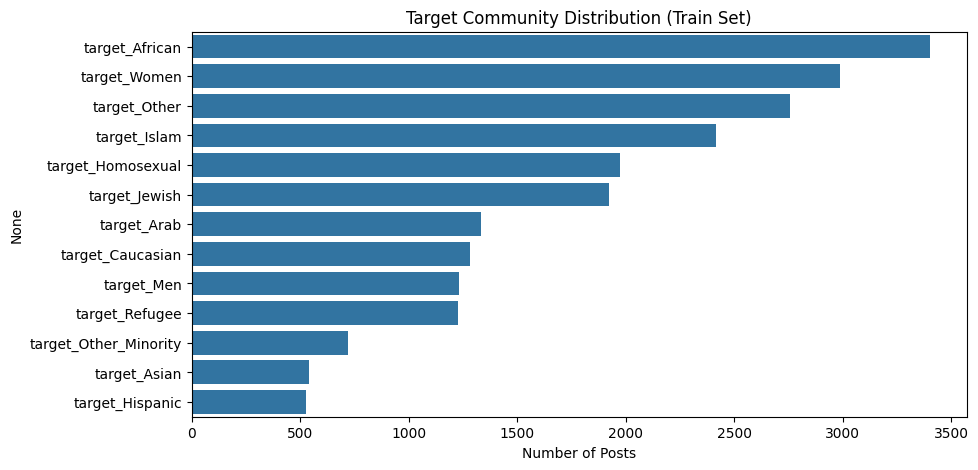

In [ ]:
target_cols = [c for c in train_df.columns if c.startswith('target_')]
target_sums = train_df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=target_sums.values, y=target_sums.index)
plt.title('Target Community Distribution (Train Set)')
plt.xlabel('Number of Posts')
plt.show()

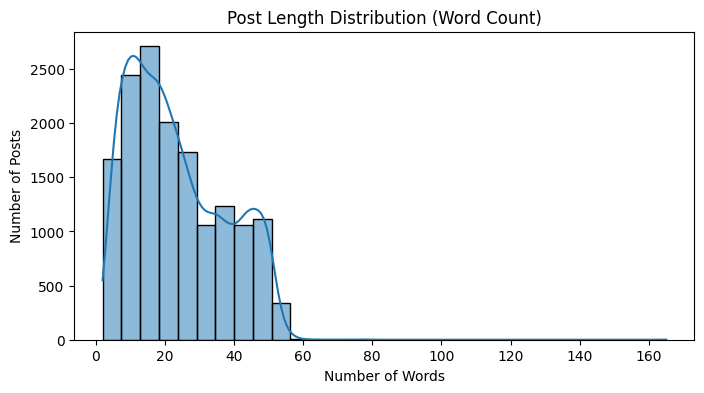

count    15383.000000
mean        23.465579
std         13.804535
min          2.000000
25%         12.000000
50%         21.000000
75%         34.000000
max        165.000000
Name: word_count, dtype: float64


In [ ]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,4))
sns.histplot(train_df['word_count'], bins=30, kde=True)
plt.title('Post Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Posts')
plt.show()

print(train_df['word_count'].describe())

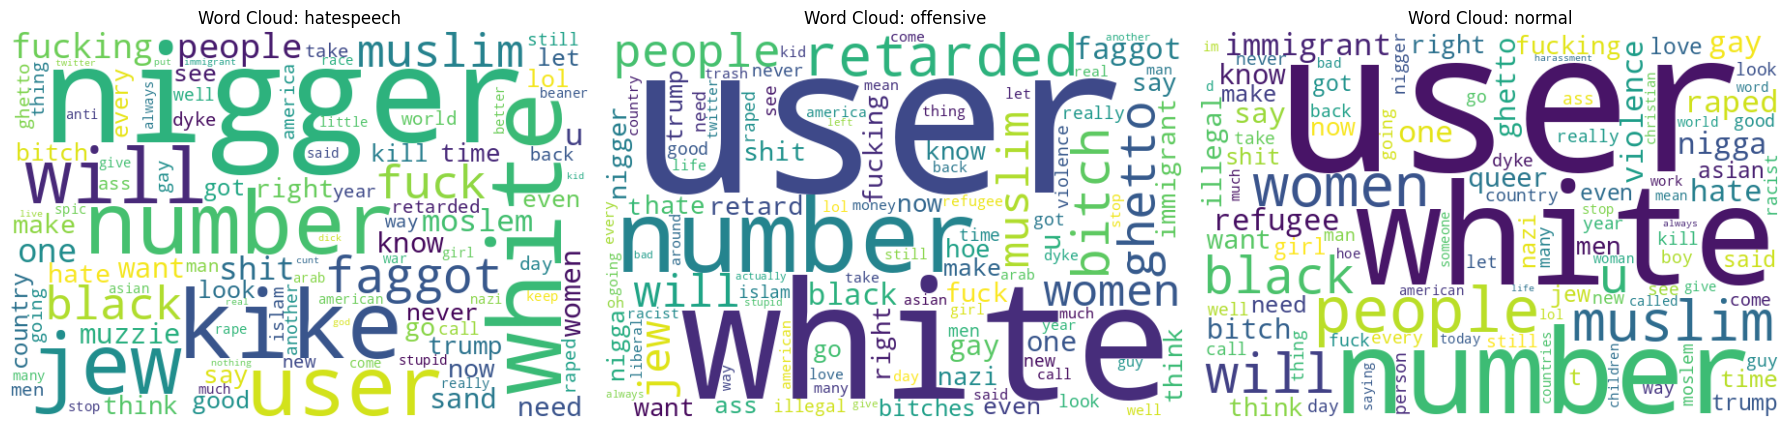

In [ ]:
from wordcloud import WordCloud

def plot_wordcloud(df, label_name, ax):
    text_subset = " ".join(df[df['final_label_name'] == label_name]['text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                    max_words=100, collocations=False).generate(text_subset)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud: {label_name}')
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, label_name in zip(axes, ['hatespeech', 'offensive', 'normal']):
    plot_wordcloud(train_df, label_name, ax)
plt.tight_layout()
plt.show()

In [ ]:
# Look at one hatespeech example's rationale — which words did annotators flag as toxic?
example = dataset['train'][0]
tokens = example['post_tokens']
rationales = example['rationales']  # list of lists, one per annotator who gave rationale

print("Post:", " ".join(tokens))
print("\nAnnotator labels:", example['annotators']['label'])
print("\nRationale arrays (1 = flagged word, aligned with tokens):")
for i, r in enumerate(rationales):
    flagged_words = [tok for tok, flag in zip(tokens, r) if flag == 1]
    print(f"Annotator {i+1} flagged words: {flagged_words}")

Post: u really think i would not have been raped by feral hindu or muslim back in india or bangladesh and a neo nazi would rape me as well just to see me cry

Annotator labels: [0, 2, 2]

Rationale arrays (1 = flagged word, aligned with tokens):
Annotator 1 flagged words: ['raped', 'neo', 'nazi', 'would', 'rape']
Annotator 2 flagged words: ['raped', 'feral', 'hindu', 'muslim', 'neo', 'nazi']


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
def clean_text(text):
    text = text.lower()  # lowercase everything so "Hate" and "hate" are treated the same

    text = re.sub(r'<user>|user|<number>|number', '', text)
    # removes the anonymization placeholder tokens we found in Task 2's word clouds
    # (these carry no class signal and were dominating the visualizations)

    text = re.sub(r'http\S+|www\S+', '', text)  # remove any URLs (leftover web links, if present)

    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation, digits, special characters
    # keeps only alphabetic words — toxic text often has symbols/numbers used as obfuscation,
    # but for this first clean pass we strip them for simplicity

    text = re.sub(r'\s+', ' ', text).strip()  # collapse multiple spaces into one, trim ends

    return text

In [ ]:
def tokenize_and_filter(text):
    tokens = word_tokenize(text)  # split cleaned text into individual word tokens

    tokens = [t for t in tokens if t not in stop_words]
    # remove stopwords (e.g. "the", "is", "and") — they add noise, not classification signal

    tokens = [t for t in tokens if len(t) > 1]
    # drop single-character leftover tokens (often noise from the cleaning step above)

    return tokens

In [ ]:
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]
    # reduces words to their dictionary base form (e.g. "raped" -> "rape", "muslims" -> "muslim")
    # chosen over stemming because lemmatization keeps real, readable words —
    # important here since word clouds/explainability (Task 10) need interpretable tokens

In [ ]:
def preprocess_pipeline(text):
    text = clean_text(text)              # step 1: lowercase + remove placeholders/URLs/punctuation
    tokens = tokenize_and_filter(text)   # step 2: tokenize + remove stopwords/short tokens
    tokens = lemmatize_tokens(tokens)    # step 3: lemmatize to base word forms
    return " ".join(tokens)              # rejoin into a clean string for TF-IDF/embedding input

# Apply to all three splits
train_df['clean_text'] = train_df['text'].apply(preprocess_pipeline)
val_df['clean_text'] = val_df['text'].apply(preprocess_pipeline)
test_df['clean_text'] = test_df['text'].apply(preprocess_pipeline)

# Quick before/after check
print("BEFORE:", train_df['text'].iloc[0])
print("AFTER :", train_df['clean_text'].iloc[0])

BEFORE: u really think i would not have been raped by feral hindu or muslim back in india or bangladesh and a neo nazi would rape me as well just to see me cry
AFTER : really think would raped feral hindu muslim back india bangladesh neo nazi would rape well see cry


In [ ]:
train_df.to_csv('/content/train_processed.csv', index=False)
val_df.to_csv('/content/val_processed.csv', index=False)
test_df.to_csv('/content/test_processed.csv', index=False)
print("Saved successfully")

Saved successfully


In [ ]:
empty_after_cleaning = (train_df['clean_text'].str.strip() == '').sum()
print(f"Posts that became empty after preprocessing: {empty_after_cleaning}")

Posts that became empty after preprocessing: 0


In [ ]:
# Find and inspect the empty one before dropping, just to confirm it's genuinely junk
empty_row = train_df[train_df['clean_text'].str.strip() == '']
print(empty_row[['id', 'text', 'clean_text']])

Empty DataFrame
Columns: [id, text, clean_text]
Index: []


In [ ]:
train_df = train_df[train_df['clean_text'].str.strip() != ''].reset_index(drop=True)
print(train_df.shape)


(15382, 21)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features caps vocabulary size to the top N most informative words (keeps it manageable)
# ngram_range=(1,2) captures both single words and two-word phrases (e.g. "hate speech")
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)

# fit on train only, then transform all splits (avoids data leakage from val/test)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf = tfidf.transform(val_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (15382, 5000)
Val TF-IDF shape: (1922, 5000)
Test TF-IDF shape: (1924, 5000)


In [ ]:
# quick peek at some of the learned vocabulary/n-grams
import random
vocab_sample = random.sample(list(tfidf.vocabulary_.keys()), 15)
print(vocab_sample)

['deep', 'spot', 'despise', 'yet another', 'development', 'hot', 'saw', 'child support', 'expose', 'thus', 'harsh', 'street shitter', 'basic', 'need help', 'attacker']


In [ ]:
# Main 3-class toxicity target
y_train_label = train_df['final_label']
y_val_label = val_df['final_label']
y_test_label = test_df['final_label']

# Multi-label target-community matrix (the 13 target_ columns)
target_cols = [c for c in train_df.columns if c.startswith('target_')]
y_train_targets = train_df[target_cols]
y_val_targets = val_df[target_cols]
y_test_targets = test_df[target_cols]

print(y_train_targets.shape)

(15382, 13)


In [ ]:
print((val_df['clean_text'].str.strip() == '').sum())
print((test_df['clean_text'].str.strip() == '').sum())

0
0


In [ ]:
!pip install gensim -q

In [ ]:
from gensim.models import Word2Vec

# Word2Vec needs tokenized input (list of word-lists), not raw strings
train_tokens = train_df['clean_text'].apply(lambda x: x.split())

# train Word2Vec on our own corpus (domain-specific — learns hate-speech-relevant word relationships)
w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=2, workers=4, sg=1)
# vector_size=100 -> each word becomes a 100-dim vector
# window=5 -> looks at 5 words on either side for context
# sg=1 -> uses skip-gram (generally better for smaller/specialized corpora than CBOW)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 10362


In [ ]:
# quick sanity check: does the model learn meaningful relationships?
print(w2v_model.wv.most_similar('hate', topn=5))

[('fucking', 0.8734921216964722), ('love', 0.8547422289848328), ('much', 0.847443699836731), ('idiot', 0.8372683525085449), ('believe', 0.8358646631240845)]


In [ ]:
# Build an embedding matrix aligned to a Keras/PyTorch tokenizer's word index (needed for Task 8's LSTM)
# We'll build the actual tokenizer in Task 8, but let's save the trained Word2Vec model now
w2v_model.save("word2vec_hatexplain.model")

In [ ]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 10362


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

In [ ]:
# multi_class setup handled internally by sklearn for 3-class problems
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
# class_weight='balanced' helps since our classes aren't perfectly equal in size

log_reg.fit(X_train_tfidf, y_train_label)

y_pred_label = log_reg.predict(X_val_tfidf)
print(classification_report(y_val_label, y_pred_label, target_names=['hatespeech','normal','offensive']))

              precision    recall  f1-score   support

  hatespeech       0.70      0.70      0.70       593
      normal       0.66      0.67      0.66       781
   offensive       0.50      0.49      0.49       548

    accuracy                           0.63      1922
   macro avg       0.62      0.62      0.62      1922
weighted avg       0.63      0.63      0.63      1922



In [ ]:
# OneVsRestClassifier trains one binary classifier per target-community column
ovr_log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))

ovr_log_reg.fit(X_train_tfidf, y_train_targets)

y_pred_targets = ovr_log_reg.predict(X_val_tfidf)
print(classification_report(y_val_targets, y_pred_targets, target_names=target_cols))

                       precision    recall  f1-score   support

       target_African       0.76      0.83      0.79       419
         target_Islam       0.78      0.85      0.81       299
         target_Women       0.56      0.68      0.61       383
        target_Jewish       0.90      0.86      0.88       241
    target_Homosexual       0.81      0.90      0.85       251
         target_Other       0.42      0.57      0.48       366
       target_Refugee       0.61      0.76      0.67       157
          target_Arab       0.46      0.72      0.56       170
     target_Caucasian       0.38      0.80      0.52       158
           target_Men       0.15      0.36      0.21       161
         target_Asian       0.60      0.73      0.66        67
      target_Hispanic       0.43      0.67      0.52        72
target_Other_Minority       0.13      0.40      0.20        87

            micro avg       0.53      0.73      0.61      2831
            macro avg       0.54      0.70      0.60 

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

In [ ]:
svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train_tfidf, y_train_label)

y_pred_label_svm = svm_model.predict(X_val_tfidf)
print(classification_report(y_val_label, y_pred_label_svm, target_names=['hatespeech','normal','offensive']))

              precision    recall  f1-score   support

  hatespeech       0.68      0.68      0.68       593
      normal       0.65      0.68      0.66       781
   offensive       0.46      0.42      0.44       548

    accuracy                           0.61      1922
   macro avg       0.60      0.60      0.59      1922
weighted avg       0.60      0.61      0.61      1922



In [ ]:
ovr_svm = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=2000))
ovr_svm.fit(X_train_tfidf, y_train_targets)

y_pred_targets_svm = ovr_svm.predict(X_val_tfidf)
print(classification_report(y_val_targets, y_pred_targets_svm, target_names=target_cols, zero_division=0))

                       precision    recall  f1-score   support

       target_African       0.75      0.78      0.77       419
         target_Islam       0.73      0.84      0.78       299
         target_Women       0.49      0.63      0.55       383
        target_Jewish       0.86      0.86      0.86       241
    target_Homosexual       0.77      0.81      0.79       251
         target_Other       0.35      0.49      0.41       366
       target_Refugee       0.55      0.71      0.62       157
          target_Arab       0.50      0.66      0.57       170
     target_Caucasian       0.37      0.65      0.47       158
           target_Men       0.15      0.31      0.20       161
         target_Asian       0.58      0.66      0.62        67
      target_Hispanic       0.49      0.56      0.52        72
target_Other_Minority       0.11      0.28      0.16        87

            micro avg       0.51      0.67      0.58      2831
            macro avg       0.52      0.63      0.56 

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 10000   # cap vocabulary size
MAX_LEN = 50         # based on Task 2 EDA: covers the vast majority of posts (75th percentile was 34)

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(train_df['clean_text'])

X_train_seq = keras_tokenizer.texts_to_sequences(train_df['clean_text'])
X_val_seq = keras_tokenizer.texts_to_sequences(val_df['clean_text'])
X_test_seq = keras_tokenizer.texts_to_sequences(test_df['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

print(X_train_pad.shape)

(15382, 50)


In [ ]:
import numpy as np

EMBED_DIM = 100  # matches the vector_size we used when training Word2Vec in Task 5

word_index = keras_tokenizer.word_index
embedding_matrix = np.zeros((MAX_VOCAB, EMBED_DIM))

found, missing = 0, 0
for word, idx in word_index.items():
    if idx >= MAX_VOCAB:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
        found += 1
    else:
        missing += 1   # word not in our Word2Vec vocab -> stays as zero vector

print(f"Words found in Word2Vec: {found}, missing: {missing}")

Words found in Word2Vec: 9998, missing: 1


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Convert toxicity label to one-hot for the 3-class output head
y_train_label_cat = to_categorical(y_train_label, num_classes=3)
y_val_label_cat = to_categorical(y_val_label, num_classes=3)

input_layer = Input(shape=(MAX_LEN,))

embedding_layer = Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM,
                             weights=[embedding_matrix], input_length=MAX_LEN,
                             trainable=True)(input_layer)
# trainable=True lets the model fine-tune our Word2Vec vectors further during training

bilstm_layer = Bidirectional(LSTM(64, return_sequences=False))(embedding_layer)
dropout_layer = Dropout(0.3)(bilstm_layer)  # reduces overfitting

# Two output heads: one for toxicity (3-class softmax), one for target-communities (13-label sigmoid)
toxicity_output = Dense(3, activation='softmax', name='toxicity_output')(dropout_layer)
target_output = Dense(13, activation='sigmoid', name='target_output')(dropout_layer)

model = Model(inputs=input_layer, outputs=[toxicity_output, target_output])

model.compile(
    optimizer='adam',
    loss={'toxicity_output': 'categorical_crossentropy', 'target_output': 'binary_crossentropy'},
    metrics={'toxicity_output': 'accuracy', 'target_output': 'accuracy'}
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 50, 100)   │  1,000,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 128)       │     84,480 │ embedding_2[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ toxicity_output     │ (None, 3)         │        387 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ target_output       │ (None, 13)        │      1,677 │ dropout_2[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,086,544 (4.14 MB)

 Trainable params: 1,086,544 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad,
    {'toxicity_output': y_train_label_cat, 'target_output': y_train_targets.values},
    validation_data=(X_val_pad, {'toxicity_output': y_val_label_cat, 'target_output': y_val_targets.values}),
    epochs=10,
    batch_size=32
)

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.2246 - target_output_accuracy: 0.2769 - target_output_loss: 0.3296 - toxicity_output_accuracy: 0.5811 - toxicity_output_loss: 0.8949 - val_loss: 1.1212 - val_target_output_accuracy: 0.3252 - val_target_output_loss: 0.3061 - val_toxicity_output_accuracy: 0.6556 - val_toxicity_output_loss: 0.8040
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.9824 - target_output_accuracy: 0.3598 - target_output_loss: 0.2926 - toxicity_output_accuracy: 0.7084 - toxicity_output_loss: 0.6900 - val_loss: 1.0730 - val_target_output_accuracy: 0.4344 - val_target_output_loss: 0.2827 - val_toxicity_output_accuracy: 0.6535 - val_toxicity_output_loss: 0.7794
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.8225 - target_output_accuracy: 0.4485 - target_output_loss: 0.2691 - toxicity_output_accuracy: 0.7758 - toxicity_output_loss: 0.5534 - val_loss: 1.1157 - val_target_output_accuracy: 0.4776 - val_target_output_loss: 0.2

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_val_pad)
y_pred_toxicity = np.argmax(y_pred[0], axis=1)
y_pred_target = (y_pred[1] > 0.5).astype(int)  # threshold sigmoid outputs at 0.5

print("=== Toxicity Classification ===")
print(classification_report(y_val_label, y_pred_toxicity, target_names=['hatespeech','normal','offensive']))

print("=== Target Community Classification ===")
print(classification_report(y_val_targets, y_pred_target, target_names=target_cols, zero_division=0))

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
=== Toxicity Classification ===
              precision    recall  f1-score   support

  hatespeech       0.65      0.62      0.64       593
      normal       0.64      0.58      0.61       781
   offensive       0.41      0.49      0.45       548

    accuracy                           0.57      1922
   macro avg       0.57      0.56      0.56      1922
weighted avg       0.58      0.57      0.57      1922

=== Target Community Classification ===
                       precision    recall  f1-score   support

       target_African       0.80      0.72      0.76       419
         target_Islam       0.81      0.72      0.76       299
         target_Women       0.67      0.25      0.36       383
        target_Jewish       0.94      0.79      0.86       241
    target_Homosexual       0.84      0.71      0.77       251
         target_Other       0.55      0.13      0.21       366
       target_Refugee       0.72      0.41      0.52       157
   

In [ ]:
import tensorflow as tf

# compute how much rarer each label is (negatives/positives) -> higher weight for rarer labels
pos_counts = y_train_targets.sum(axis=0).values
neg_counts = y_train_targets.shape[0] - pos_counts
pos_weights = tf.constant(neg_counts / pos_counts, dtype=tf.float32)

def weighted_binary_crossentropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)
    # positive examples get scaled up by pos_weights; negatives stay weight 1
    weight_vector = y_true * pos_weights + (1 - y_true)
    return tf.reduce_mean(weight_vector * bce)

In [ ]:
# Rebuild the same architecture (keeps toxicity_output loss as-is, only target_output loss changes)
input_layer = Input(shape=(MAX_LEN,))
embedding_layer = Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM,
                             weights=[embedding_matrix], trainable=True)(input_layer)
bilstm_layer = Bidirectional(LSTM(64, return_sequences=False))(embedding_layer)
dropout_layer = Dropout(0.3)(bilstm_layer)

toxicity_output = Dense(3, activation='softmax', name='toxicity_output')(dropout_layer)
target_output = Dense(13, activation='sigmoid', name='target_output')(dropout_layer)

model_weighted = Model(inputs=input_layer, outputs=[toxicity_output, target_output])

model_weighted.compile(
    optimizer='adam',
    loss={'toxicity_output': 'categorical_crossentropy', 'target_output': weighted_binary_crossentropy},
    metrics={'toxicity_output': 'accuracy', 'target_output': 'accuracy'}
)

In [ ]:
history_weighted = model_weighted.fit(
    X_train_pad,
    {'toxicity_output': y_train_label_cat, 'target_output': y_train_targets.values},
    validation_data=(X_val_pad, {'toxicity_output': y_val_label_cat, 'target_output': y_val_targets.values}),
    epochs=10,
    batch_size=32
)

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.5367 - target_output_accuracy: 0.5692 - target_output_loss: 0.3911 - toxicity_output_accuracy: 0.9503 - toxicity_output_loss: 0.1458 - val_loss: 2.8046 - val_target_output_accuracy: 0.5198 - val_target_output_loss: 0.9622 - val_toxicity_output_accuracy: 0.5864 - val_toxicity_output_loss: 1.8072
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - loss: 0.4852 - target_output_accuracy: 0.5733 - target_output_loss: 0.3619 - toxicity_output_accuracy: 0.9549 - toxicity_output_loss: 0.1232 - val_loss: 3.1680 - val_target_output_accuracy: 0.5219 - val_target_output_loss: 1.0764 - val_toxicity_output_accuracy: 0.5671 - val_toxicity_output_loss: 2.0499
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 0.4453 - target_output_accuracy: 0.5755 - target_output_loss: 0.3339 - toxicity_output_accuracy: 0.9611 - toxicity_output_loss: 0.1114 - val_loss: 3.2498 - val_target_output_accuracy: 0.5442 - val_target_output_loss: 1

In [ ]:
y_pred_weighted = model_weighted.predict(X_val_pad)
y_pred_toxicity_w = np.argmax(y_pred_weighted[0], axis=1)
y_pred_target_w = (y_pred_weighted[1] > 0.5).astype(int)

print("=== Toxicity Classification (weighted model) ===")
print(classification_report(y_val_label, y_pred_toxicity_w, target_names=['hatespeech','normal','offensive']))

print("=== Target Community Classification (weighted model) ===")
print(classification_report(y_val_targets, y_pred_target_w, target_names=target_cols, zero_division=0))

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Toxicity Classification (weighted model) ===
              precision    recall  f1-score   support

  hatespeech       0.65      0.61      0.63       593
      normal       0.61      0.60      0.61       781
   offensive       0.41      0.45      0.43       548

    accuracy                           0.56      1922
   macro avg       0.56      0.55      0.56      1922
weighted avg       0.57      0.56      0.56      1922

=== Target Community Classification (weighted model) ===
                       precision    recall  f1-score   support

       target_African       0.71      0.82      0.76       419
         target_Islam       0.69      0.85      0.76       299
         target_Women       0.45      0.56      0.50       383
        target_Jewish       0.73      0.85      0.79       241
    target_Homosexual       0.74      0.92      0.82       251
         target_Other       0.33      0.56      0.42       366
       target_Refugee       0.49

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Logistic Regression
pred_label = log_reg.predict(X_test_tfidf)
pred_targets = ovr_log_reg.predict(X_test_tfidf)
logreg_test_results = {
    'toxicity_acc': accuracy_score(y_test_label, pred_label),
    'toxicity_macroF1': f1_score(y_test_label, pred_label, average='macro'),
    'target_microF1': f1_score(y_test_targets, pred_targets, average='micro'),
    'target_macroF1': f1_score(y_test_targets, pred_targets, average='macro')
}

# Linear SVM
pred_label = svm_model.predict(X_test_tfidf)
pred_targets = ovr_svm.predict(X_test_tfidf)
svm_test_results = {
    'toxicity_acc': accuracy_score(y_test_label, pred_label),
    'toxicity_macroF1': f1_score(y_test_label, pred_label, average='macro'),
    'target_microF1': f1_score(y_test_targets, pred_targets, average='micro'),
    'target_macroF1': f1_score(y_test_targets, pred_targets, average='macro')
}

# BiLSTM (weighted)
pred = model_weighted.predict(X_test_pad)
pred_label = np.argmax(pred[0], axis=1)
pred_targets = (pred[1] > 0.5).astype(int)
bilstm_test_results = {
    'toxicity_acc': accuracy_score(y_test_label, pred_label),
    'toxicity_macroF1': f1_score(y_test_label, pred_label, average='macro'),
    'target_microF1': f1_score(y_test_targets, pred_targets, average='micro'),
    'target_macroF1': f1_score(y_test_targets, pred_targets, average='macro')
}

print("Logistic Regression:", logreg_test_results)
print("Linear SVM:", svm_test_results)
print("BiLSTM (weighted):", bilstm_test_results)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Logistic Regression: {'toxicity_acc': 0.6366943866943867, 'toxicity_macroF1': 0.6253235406809794, 'target_microF1': 0.6133575647432985, 'target_macroF1': 0.602209093508952}
Linear SVM: {'toxicity_acc': 0.6226611226611226, 'toxicity_macroF1': 0.6075746229423559, 'target_microF1': 0.5773650243979223, 'target_macroF1': 0.5642322971049584}
BiLSTM (weighted): {'toxicity_acc': 0.5639293139293139, 'toxicity_macroF1': 0.5564489655323165, 'target_microF1': 0.5491554785621481, 'target_macroF1': 0.531525559060344}


In [85]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [86]:
from lime.lime_text import LimeTextExplainer
import numpy as np

def predict_proba_toxicity(texts):
    # texts: list of raw strings -> apply same preprocessing used in training
    cleaned = [preprocess_pipeline(t) for t in texts]
    tfidf_vecs = tfidf.transform(cleaned)
    return log_reg.predict_proba(tfidf_vecs)

explainer_toxicity = LimeTextExplainer(class_names=['hatespeech', 'normal', 'offensive'])

In [87]:
# Pick a real post from the validation set to explain
sample_idx = 5
sample_text = val_df['text'].iloc[sample_idx]
true_label = val_df['final_label_name'].iloc[sample_idx] if 'final_label_name' in val_df.columns else val_df['final_label'].iloc[sample_idx]

print("Text:", sample_text)
print("True label:", true_label)

exp = explainer_toxicity.explain_instance(sample_text, predict_proba_toxicity, num_features=10, labels=[0,1,2])
exp.show_in_notebook(text=True)

Text: <user> number of people being born under the poverty line all time high too but i guess let push for some retarded pseudo feminism
True label: 1


In [88]:
print("Text:", sample_text)
print("True label:", true_label)

exp_list_hatespeech = exp.as_list(label=0)
exp_list_normal = exp.as_list(label=1)
exp_list_offensive = exp.as_list(label=2)

print("\nTop words → 'hatespeech':")
for word, weight in exp_list_hatespeech:
    print(f"  {word}: {weight:.3f}")

print("\nTop words → 'normal':")
for word, weight in exp_list_normal:
    print(f"  {word}: {weight:.3f}")

print("\nTop words → 'offensive':")
for word, weight in exp_list_offensive:
    print(f"  {word}: {weight:.3f}")

Text: <user> number of people being born under the poverty line all time high too but i guess let push for some retarded pseudo feminism
True label: 1

Top words → 'hatespeech':
  high: 0.068
  born: 0.054
  line: -0.050
  people: -0.046
  guess: 0.046
  let: 0.043
  push: 0.038
  poverty: -0.033
  retarded: -0.021
  time: 0.013

Top words → 'normal':
  retarded: -0.328
  poverty: 0.079
  born: 0.073
  people: 0.068
  let: -0.050
  line: 0.042
  time: 0.032
  high: 0.010
  push: 0.008
  guess: -0.008

Top words → 'offensive':
  retarded: 0.349
  born: -0.126
  high: -0.078
  push: -0.046
  poverty: -0.046
  time: -0.045
  guess: -0.038
  people: -0.021
  line: 0.009
  let: 0.006


In [89]:
# Find this same post's original rationale from the dataset object (if it's in train, not val - adjust as needed)
# For now, let's check a few posts and manually note whether LIME's top words overlap with likely toxic terms

exp_list = exp.as_list(label=0)  # label=0 is 'hatespeech' - check against your class_names order
print("Top words driving 'hatespeech' prediction:")
for word, weight in exp_list:
    print(f"  {word}: {weight:.3f}")

Top words driving 'hatespeech' prediction:
  high: 0.068
  born: 0.054
  line: -0.050
  people: -0.046
  guess: 0.046
  let: 0.043
  push: 0.038
  poverty: -0.033
  retarded: -0.021
  time: 0.013


In [90]:
import joblib

joblib.dump(log_reg, 'log_reg_model.pkl')
joblib.dump(ovr_log_reg, 'ovr_log_reg_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Saved successfully")

Saved successfully


In [91]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 61.9 MB/s eta 0:00:00


In [92]:
%%writefile app.py
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# --- Same preprocessing pipeline used during training ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<user>|user|<number>|number', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_and_filter(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

def preprocess_pipeline(text):
    text = clean_text(text)
    tokens = tokenize_and_filter(text)
    tokens = lemmatize_tokens(tokens)
    return " ".join(tokens)

# --- Load trained model + vectorizer ---
log_reg = joblib.load('log_reg_model.pkl')
ovr_log_reg = joblib.load('ovr_log_reg_model.pkl')
tfidf = joblib.load('tfidf_vectorizer.pkl')

target_cols = ['target_African', 'target_Islam', 'target_Women', 'target_Jewish',
                'target_Homosexual', 'target_Other', 'target_Refugee', 'target_Arab',
                'target_Caucasian', 'target_Men', 'target_Asian', 'target_Hispanic',
                'target_Other_Minority']

label_names = ['hatespeech', 'normal', 'offensive']

# --- UI ---
st.title("Hate Speech & Toxicity Detection Dashboard")
st.write("Enter a social media comment to analyze its toxicity and target community.")

user_input = st.text_area("Comment text:", height=100)

if st.button("Analyze"):
    if user_input.strip() == "":
        st.warning("Please enter some text.")
    else:
        cleaned = preprocess_pipeline(user_input)
        vec = tfidf.transform([cleaned])

        # Toxicity prediction
        tox_pred = log_reg.predict(vec)[0]
        tox_proba = log_reg.predict_proba(vec)[0]

        st.subheader("Toxicity Classification")
        st.write(f"**Predicted label:** {label_names[tox_pred]}")
        st.bar_chart({label_names[i]: tox_proba[i] for i in range(3)})

        # Target-community prediction
        target_pred = ovr_log_reg.predict(vec)[0]
        predicted_targets = [target_cols[i].replace('target_', '') for i in range(len(target_cols)) if target_pred[i] == 1]

        st.subheader("Target Community")
        if predicted_targets:
            st.write("**Detected target(s):** " + ", ".join(predicted_targets))
        else:
            st.write("No specific target community detected.")

Writing app.py


In [94]:
from pyngrok import ngrok
ngrok.set_auth_token("3KLYOlzznX7AftJXVWJDZrnuGnM_HtLa7Em1FjMKNwGn1Mc9")

In [95]:
from pyngrok import ngrok

# Kill any previous tunnels
ngrok.kill()

!streamlit run app.py &>/content/logs.txt &

import time
time.sleep(5)  # give streamlit a moment to start

public_url = ngrok.connect(8501)
print("Your dashboard is live at:", public_url)

Your dashboard is live at: NgrokTunnel: "https://repair-jitters-tractor.ngrok-free.dev" -> "http://localhost:8501"
